In [1]:
import pandas as pd
import numpy as np
from os import listdir
import re

import matplotlib.pyplot as plt

In [2]:
EXPORT_FOLDER = '../MP/Files/'

In [3]:
def CompileCSV(FOLDER : str):
    FILENAMES = [f'{FOLDER}/{file}' for file in listdir(FOLDER)[1:]]
    FILENAMES
    
    output = None
    
    for f in FILENAMES:
        if f[-4:] != '.csv':
            continue
    
        df = None
    
        ID, NAME = f.split('/')[-1].strip('.csv').split('_')
    
        df = pd.read_csv(f)
        df['Personnel_ID'] = int(ID)
        df['Personnel_Name'] = NAME
    
    
        if output is None:
            output = df.copy()
        else:
            output = pd.concat([output, df])

    return output

# Voice Actors

In [4]:
FOLDER = 'Roles/VA'

FILENAMES = [f'{FOLDER}/{file}' for file in listdir(FOLDER)[1:]]
len(FILENAMES)

14599

In [5]:
df_VA = CompileCSV(FOLDER).reset_index().drop(columns=['index'])

In [6]:
df_VA.drop(columns=['Link', 'CharacterLink'], inplace=True)
df_VA.rename(columns={
    'ID': 'Anime_ID',
    'CharacterID' : 'Character_ID',
    'CharacterRole' : 'Role',
    'CharacterFavorites' : 'Character_Favorites',
                     }, inplace=True)
df_VA

,Anime_ID,Title,Type,Season,Year,Character,Character_ID,Role,Character_Favorites,Personnel_ID,Personnel_Name
0,3588,Soul Eater,TV,Spring,2008.0,Excalibur,13046,Supporting,1574,10002,Rajkai Zoltán
1,27,Trinity Blood,TV,Spring,2005.0,"Nightroad, Abel",1672,Main,974,10002,Rajkai Zoltán
2,20,Naruto,TV,Fall,2002.0,"Gekkou, Hayate",7738,Supporting,54,10002,Rajkai Zoltán
3,47,Akira,Movie,NaN,1988.0,Yamagata,20463,Supporting,13,10002,Rajkai Zoltán
4,523,Tonari no Totoro,Movie,NaN,1988.0,"Kusakabe, Tatsuo",8047,Supporting,25,10002,Rajkai Zoltán
...,...,...,...,...,...,...,...,...,...,...,...
425145,1960,Sore Ike! Anpanman,TV,Fall,1988.0,Numatchi,114765,Supporting,0,9,Mitsuishi Kotono
425146,1960,Sore Ike! Anpanman,TV,Fall,1988.0,Marron-kun,196687,Supporting,0,9,Mitsuishi Kotono
425147,1960,Sore Ike! Anpanman,TV,Fall,1988.0,Kaginoko Key-chan,197241,Supporting,0,9,Mitsuishi Kotono
425148,1960,Sore Ike! Anpanman,TV,Fall,1988.0,Kittelion,197260,Supporting,0,9,Mitsuishi Kotono


### Remove Irrelevant Characters

In [7]:
MIN_FAVORITES = 1
df_VA = df_VA[df_VA.Character_Favorites >= MIN_FAVORITES]
df_VA.shape

(281013, 11)

## Extract the VA IDs

In [8]:
df_PersonnelsVA = df_VA.copy()
df_PersonnelsVA.Character = df_PersonnelsVA.Character.replace(',', '', regex=True)
df_PersonnelsVA = pd.merge(df_PersonnelsVA.groupby(['Personnel_ID', 'Personnel_Name'])[['Character', 'Character_ID', 'Title', 'Anime_ID', 'Year']].agg(list).reset_index().set_index('Personnel_ID'),
         df_PersonnelsVA.groupby(['Personnel_ID']).Year.max(),
         on='Personnel_ID',
        how='left').rename(columns={'Year_x': 'Year', 'Year_y': 'Latest_Work'})

df_PersonnelsVA.to_pickle(EXPORT_FOLDER+ 'Personnels_VA.pkl')
df_PersonnelsVA

,Personnel_Name,Character,Character_ID,Title,Anime_ID,Year,Latest_Work
Personnel_ID,,,,,,,
1,Seki Tomokazu,"[Shinazugawa Sanemi, Hoshimiya Rekka, Honekawa...","[151149, 140499, 8261, 8079, 73589, 2514, 2606...","[Kimetsu no Yaiba Movie: Mugen Jou-hen, Enen n...","[59192, 51818, 59980, 59914, 59226, 55830, 568...","[2025.0, 2025.0, 2025.0, 2025.0, 2025.0, nan, ...",2025.0
2,Sugita Tomokazu,"[Sakata Gintoki, Smart Ansem, Himejima Gyoumei...","[672, 251334, 151146, 187171, 119733, 33788, 1...","[3-nen Z-gumi Ginpachi-sensei, Nageki no Boure...","[54757, 60619, 59192, 60083, 59406, 59914, 589...","[2025.0, 2025.0, 2025.0, 2025.0, 2025.0, 2025....",2025.0
3,Yukino Satsuki,"[Shimura Tae, Shimura Tae, Hiiragi, Shihouin Y...","[2944, 2944, 19023, 908, 87115, 151102, 908, 1...","[3-nen Z-gumi Ginpachi-sensei, Gintama on Thea...","[54757, 59688, 55823, 56784, 57864, 56785, 539...","[2025.0, 2024.0, 2024.0, 2024.0, 2024.0, 2024....",2025.0
4,Hirano Aya,"[Antoinette Marie, Antoinette Marie, Kazamaki ...","[1701, 1701, 256815, 6273, 5186, 14117, 5186, ...","[Versailles no Bara (Movie), Verbara Mini!, Ma...","[52967, 60783, 59632, 56894, 60063, 56538, 497...","[2025.0, 2025.0, nan, 2024.0, 2024.0, 2024.0, ...",2025.0
5,Suzumura Kenichi,"[Okita Sougo, Iguro Obanai, Hinawa Takehisa, S...","[2282, 151148, 133771, 42711, 194489, 51153, 2...","[3-nen Z-gumi Ginpachi-sensei, Kimetsu no Yaib...","[54757, 59192, 51818, 50855, 57217, 49785, 557...","[2025.0, 2025.0, 2025.0, 2024.0, 2024.0, 2024....",2025.0
...,...,...,...,...,...,...,...
59879,Haruka Megumi,"[Ichinose Riko, Ichinose Riko, Reina]","[46677, 46677, 39814]","[Rin x Sen + Ran -> Sem: Cross Mix, Ran->Sem: ...","[18525, 10458, 8654]","[2013.0, 2011.0, 2010.0]",2013.0
59883,Matalon Adam,[Asuka Ryou],[4092],[Devilman: Tanjou-hen],[2354],[1987.0],1987.0
59884,Balkan Liza,"[Mizuno Ami, Mizuno Ami]","[2366, 2366]","[Bishoujo Senshi Sailor Moon SuperS, Bishoujo ...","[1239, 532]","[1995.0, 1994.0]",1995.0


### Continue Cleaning df_VA

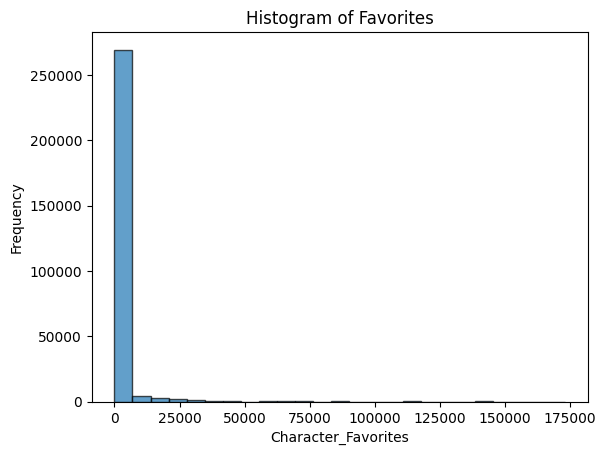

In [9]:
df_VA['Character_Favorites'].plot(kind='hist', bins=25, edgecolor='black', alpha=0.7)
plt.title('Histogram of Favorites')
plt.xlabel('Character_Favorites')
plt.show()

In [10]:
df_VA.Role.value_counts()

Role
Supporting    199078
Main           81935
Name: count, dtype: int64

In [11]:
df_VA = pd.get_dummies(df_VA, columns=['Role'])

In [12]:
df_VA.info()

<class 'pandas.core.frame.DataFrame'>
Index: 281013 entries, 0 to 425149
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Anime_ID             281013 non-null  int64  
 1   Title                281013 non-null  object 
 2   Type                 280592 non-null  object 
 3   Season               182287 non-null  object 
 4   Year                 280592 non-null  float64
 5   Character            281013 non-null  object 
 6   Character_ID         281013 non-null  int64  
 7   Character_Favorites  281013 non-null  int64  
 8   Personnel_ID         281013 non-null  int64  
 9   Personnel_Name       281013 non-null  object 
 10  Role_Main            281013 non-null  bool   
 11  Role_Supporting      281013 non-null  bool   
dtypes: bool(2), float64(1), int64(4), object(5)
memory usage: 24.1+ MB


In [13]:
df_VA.to_csv(EXPORT_FOLDER + 'VA_Raw.csv')

In [14]:
df_VA_MBA = pd.DataFrame(df_VA.groupby('Anime_ID')[['Title', 'Personnel_ID', 'Personnel_Name', 'Character']].agg(list))
df_VA_MBA['Title'] = df_VA_MBA['Title'].apply(lambda x : x[0])

df_VA_MBA.to_pickle(EXPORT_FOLDER + 'MBA_VA.pkl')
df_VA_MBA

,Title,Personnel_ID,Personnel_Name,Character
Anime_ID,,,,
1,Cowboy Bebop,"[10004, 10020, 10020, 10021, 10024, 10024, 100...","[Vasconcellos Jorge, Patiño Marco, Patiño Marc...","[Bob, Solensan, Asimov, Vicious, Spiegel, Spik..."
5,Cowboy Bebop: Tengoku no Tobira,"[10004, 10028, 10030, 10155, 10155, 1019, 1059...","[Vasconcellos Jorge, Atala Yamil, Ramirez Alfo...","[Bob, Spiegel, Spike, Black, Jet, Jobim, Anton..."
6,Trigun,"[10021, 1006, 1025, 1025, 10696, 1096, 1097, 1...","[Vilchis José Gilberto, Forstadt Rebecca, Magn...","[the Hornfreak, Midvalley, Elizabeth, Vash the..."
7,Witch Hunter Robin,"[10593, 1088, 1090, 10, 11920, 1268, 1286, 12,...","[Auer Dominik, Magnaghi Debora, Pacotto Emanue...","[Sakaki, Haruto, Sena, Robin, Doujima, Yurika,..."
8,Bouken Ou Beet,"[112, 1138, 145, 1526, 201, 201, 259, 357, 447...","[Midorikawa Hikaru, Cason Chri, Grant Tiffany,...","[Zenon, Grunide, Beet, Slade, Zenon, Shagi, Sh..."
...,...,...,...,...
61211,Mayonaka Heart Tune,"[12041, 24413, 48122]","[Ookubo Rumi, Itou Miku, Suzushiro Sayumi]","[Himekawa, Nene, Uzuki, Shinobu, Kirino, Iko]"
61227,Girls & Panzer: Motto Love Love Sakusen desu!,"[10765, 17007, 17009, 885, 9593]","[Kayano Ai, Ozaki Mami, Nakagami Ikumi, Iguchi...","[Takebe, Saori, Isuzu, Hana, Akiyama, Yukari, ..."
61276,Mikata ga Yowasugite Hojo Mahou ni Tesshiteita...,[55585],[Umeda Shuuichirou],"[Ygret, Alec]"


# Staff

In [4]:
FOLDER = 'Roles/Staff'

FILENAMES = [f'{FOLDER}/{file}' for file in listdir(FOLDER)[1:]]
len(FILENAMES)

14183

In [5]:
df_Staff = CompileCSV(FOLDER).reset_index().drop(columns=['index'])
df_Staff

,ID,Title,Link,Roles,Type,Season,Year,Score,Members,Personnel_ID,Personnel_Name
0,10547,Oretachi ni Tsubasa wa Nai: Hadairo Ritsu Kyuu...,https://myanimelist.net/anime/10547/Oretachi_n...,Original Creator,OVA,NaN,2011.0,6.39,13924.0,10000,Navel
1,9922,Oretachi ni Tsubasa wa Nai: Under the Innocent...,https://myanimelist.net/anime/9922/Oretachi_ni...,Original Creator,TV,Spring,2011.0,6.63,91565.0,10000,Navel
2,79,Shuffle!,https://myanimelist.net/anime/79/Shuffle,Original Creator,TV,Summer,2005.0,7.01,285765.0,10000,Navel
3,1836,Shuffle! Memories,https://myanimelist.net/anime/1836/Shuffle_Mem...,Original Creator,TV,Winter,2007.0,6.52,57551.0,10000,Navel
4,7396,Shuffle! Prologue,https://myanimelist.net/anime/7396/Shuffle_Pro...,Original Creator,OVA,NaN,2005.0,6.64,18797.0,10000,Navel
...,...,...,...,...,...,...,...,...,...,...,...
245272,532,Bishoujo Senshi Sailor Moon S,https://myanimelist.net/anime/532/Bishoujo_Sen...,Theme Song Performance (ED),TV,Spring,1994.0,7.90,153180.0,9,Mitsuishi Kotono
245273,870,Dragon Half,https://myanimelist.net/anime/870/Dragon_Half,Theme Song Performance (ED),OVA,NaN,1993.0,6.84,23683.0,9,Mitsuishi Kotono
245274,2759,Evangelion Movie 1: Jo,https://myanimelist.net/anime/2759/Evangelion_...,Inserted Song Performance,Movie,NaN,2007.0,8.00,589850.0,9,Mitsuishi Kotono
245275,2081,Makeruna! Makendou,https://myanimelist.net/anime/2081/Makeruna_Ma...,Theme Song Performance (ED),OVA,NaN,1995.0,5.49,2251.0,9,Mitsuishi Kotono


In [6]:
df_Staff.drop(columns=['Link'], inplace=True)
df_Staff.rename(columns={'ID':'Anime_ID'}, inplace=True)

## Extract the Staff IDs

In [7]:
df_Staff

,Anime_ID,Title,Roles,Type,Season,Year,Score,Members,Personnel_ID,Personnel_Name
0,10547,Oretachi ni Tsubasa wa Nai: Hadairo Ritsu Kyuu...,Original Creator,OVA,NaN,2011.0,6.39,13924.0,10000,Navel
1,9922,Oretachi ni Tsubasa wa Nai: Under the Innocent...,Original Creator,TV,Spring,2011.0,6.63,91565.0,10000,Navel
2,79,Shuffle!,Original Creator,TV,Summer,2005.0,7.01,285765.0,10000,Navel
3,1836,Shuffle! Memories,Original Creator,TV,Winter,2007.0,6.52,57551.0,10000,Navel
4,7396,Shuffle! Prologue,Original Creator,OVA,NaN,2005.0,6.64,18797.0,10000,Navel
...,...,...,...,...,...,...,...,...,...,...
245272,532,Bishoujo Senshi Sailor Moon S,Theme Song Performance (ED),TV,Spring,1994.0,7.90,153180.0,9,Mitsuishi Kotono
245273,870,Dragon Half,Theme Song Performance (ED),OVA,NaN,1993.0,6.84,23683.0,9,Mitsuishi Kotono
245274,2759,Evangelion Movie 1: Jo,Inserted Song Performance,Movie,NaN,2007.0,8.00,589850.0,9,Mitsuishi Kotono
245275,2081,Makeruna! Makendou,Theme Song Performance (ED),OVA,NaN,1995.0,5.49,2251.0,9,Mitsuishi Kotono


In [10]:
df_PersonnelsStaff = df_Staff.copy()
df_PersonnelsStaff = pd.merge(df_PersonnelsStaff.groupby(['Personnel_ID', 'Personnel_Name'])[['Title', 'Anime_ID', 'Type', 'Year', 'Score', 'Members']].agg(list).reset_index().set_index('Personnel_ID'),
         df_PersonnelsStaff.groupby(['Personnel_ID']).Year.max(),
         on='Personnel_ID',
        how='left').rename(columns={'Year_x': 'Year', 'Year_y': 'Latest_Work'})

df_PersonnelsStaff.to_pickle( EXPORT_FOLDER + 'Personnels_Staff.pkl')
df_PersonnelsStaff

,Personnel_Name,Title,Anime_ID,Type,Year,Score,Members,Latest_Work
Personnel_ID,,,,,,,,
1,Seki Tomokazu,"[Anime Tenchou, Haiyore! Nyaruko-san W, Haruka...","[3080, 15699, 247, 258, 34825, 1628, 4560, 300...","[OVA, TV, TV, OVA, TV, TV, OVA, TV, ONA, OVA, ...","[2002.0, 2013.0, 2004.0, 2003.0, 2017.0, 2002....","[6.05, 7.2, 6.99, 6.13, 6.95, 5.96, 5.09, 7.33...","[11845.0, 187148.0, 26222.0, 19088.0, 204250.0...",2017.0
2,Sugita Tomokazu,"[Binan Koukou Chikyuu Bouei-bu Eternal Love!, ...","[59406, 32483, 33798, 59, 42571, 918, 11013, 1...","[Movie, TV, TV Special, TV, TV, TV, TV, TV, TV...","[2025.0, 2016.0, 2016.0, 2002.0, 2020.0, 2006....","[nan, 6.66, 5.9, 7.39, 5.55, 8.93, 7.36, 7.12,...","[1964.0, 65550.0, 4768.0, 498596.0, 79100.0, 1...",2025.0
3,Yukino Satsuki,"[Gun x Sword, Higurashi no Naku Koro ni Kira, ...","[411, 10491, 191, 15651, 1772]","[TV, OVA, TV Special, TV, OVA]","[2005.0, 2011.0, 2000.0, 2013.0, 1998.0]","[7.24, 6.53, 7.3, 7.23, 5.17]","[81136.0, 89662.0, 59656.0, 37326.0, 2861.0]",2013.0
4,Hirano Aya,"[Akaneiro ni Somaru Saka, Death Note, Eyeshiel...","[4744, 1535, 15, 12049, 9982, 18393, 1858, 160...","[TV, TV, TV, Movie, OVA, OVA, TV, TV, TV, TV, ...","[2008.0, 2006.0, 2005.0, 2012.0, 2011.0, 2013....","[6.38, 8.62, 7.91, 7.38, 7.46, 7.14, 7.25, 6.2...","[154894.0, 4077380.0, 189516.0, 224857.0, 1700...",2015.0
5,Suzumura Kenichi,"[Brothers Conflict, Brothers Conflict OVA, Bus...","[15605, 25437, 3389, 36934, 11703, 15633, 2634...","[TV, OVA, TV, TV, TV, OVA, TV, TV, TV, TV, Mov...","[2013.0, 2014.0, 2008.0, 2018.0, 2012.0, 2012....","[5.89, 6.47, 6.46, 7.42, 6.71, 6.7, 7.27, 7.31...","[189678.0, 28864.0, 28679.0, 79404.0, 344378.0...",2024.0
...,...,...,...,...,...,...,...,...
59979,Nishi Eiko,"[Ame-iro Cocoa in Hawaii, Ame-iro Cocoa Series...","[33245, 35923, 40934, 50481, 51632, 37058, 159...","[TV, TV, TV, TV, TV, ONA, TV, ONA, TV, TV, TV,...","[2016.0, 2017.0, 2020.0, 2023.0, 2023.0, 2017....","[4.77, 4.77, 6.52, 6.56, 6.41, 5.89, 7.33, 7.3...","[7200.0, 5836.0, 56030.0, 164274.0, 157649.0, ...",2025.0
59980,Serizawa Haruka,"[Shinmai Renkinjutsushi no Tenpo Keiei, Tonika...","[49849, 50307, 55651]","[TV, TV, ONA]","[2022.0, 2023.0, 2023.0]","[6.62, 7.61, 7.76]","[76221.0, 270275.0, 66945.0]",2023.0
59982,Humbreader,"[Boruto: Naruto Next Generations, Dragon Quest...","[34566, 40906, 57635, 59265, 42340, 40957, 51098]","[TV, TV, TV, TV, TV, TV, TV]","[2017.0, 2020.0, 2024.0, 2025.0, 2021.0, 2021....","[6.0, 7.73, 7.6, 6.84, 7.22, 6.68, 6.06]","[897477.0, 77055.0, 54701.0, 48255.0, 241254.0...",2025.0


### Continue cleaning

In [11]:
df_Staff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245277 entries, 0 to 245276
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Anime_ID        245277 non-null  int64  
 1   Title           245277 non-null  object 
 2   Roles           245277 non-null  object 
 3   Type            243103 non-null  object 
 4   Season          151527 non-null  object 
 5   Year            243103 non-null  float64
 6   Score           237297 non-null  float64
 7   Members         245277 non-null  float64
 8   Personnel_ID    245277 non-null  int64  
 9   Personnel_Name  245277 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 18.7+ MB


### Although some Anime Scores are null, their Members are all complete.

In [12]:
df_Staff[df_Staff.Score.isna()]

,Anime_ID,Title,Roles,Type,Season,Year,Score,Members,Personnel_ID,Personnel_Name
43,39002,Sore Ike! Anpanman: Kirameke! Ice no Kuni no V...,ADR Director,Movie,NaN,2019.0,NaN,441.0,10020,Patiño Marco
44,32676,Sore Ike! Anpanman: Omocha no Hoshi no Nanda t...,ADR Director,Movie,NaN,2016.0,NaN,482.0,10020,Patiño Marco
76,22641,Kerokero Keroppi no Bikkuri! Obakeyashiki,Screenplay,OVA,NaN,1996.0,NaN,419.0,10027,Nishizono Satoru
87,11497,Sore Ike! Zukkoke Sannin-gumi,"Script, Series Composition",TV,Spring,2004.0,NaN,439.0,10027,Nishizono Satoru
95,55238,Tekuteku,Theme Song Performance,Music,NaN,2005.0,NaN,110.0,10033,Spitz
...,...,...,...,...,...,...,...,...,...,...
245083,56488,Zegapain: STA,Director,Movie,NaN,2024.0,NaN,1702.0,9974,Shimoda Masami
245092,57007,Futari de Hanbunko,Animation Director,Music,NaN,1981.0,NaN,99.0,9982,Momose Yoshiyuki
245104,3828,Maegami Tarou,"Character Design, Animation Director",TV Special,NaN,1979.0,NaN,485.0,9982,Momose Yoshiyuki
245116,22973,Sangokushi,Key Animation,TV Special,NaN,1982.0,NaN,513.0,9982,Momose Yoshiyuki


## One Hot Encode the Roles

In [13]:
def filter_strings(strings, exclude_words, replace_words):
    filtered_strings = set()  
    
    for s in strings:
        if any(word in s for word in exclude_words):
            continue

        if any(word in s for word in replace_words):
            for w in replace_words:
                s = s.replace(w, '')
            
        filtered_strings.add(s)
    
    return list(filtered_strings)

In [14]:
ROLES = filter_strings(df_Staff.Roles, ['(', ',', ')', 'Original Creator'], [])
ROLES

['Script',
 'Setting',
 'Episode Director',
 'Theme Song Lyrics',
 'Sound Effects',
 'Assistant Director',
 'Chief Producer',
 'Assistant Production Coordinat',
 'Co-Producer',
 'Series Production Director',
 'Background Art',
 'In-Between Animation',
 'Planning',
 'Dialogue Editing',
 'Production Assistant',
 'Production Coordination',
 'Animation Check',
 'Series Composition',
 'Color Design',
 'Associate Producer',
 'Original Character Design',
 'Post-Production Assistant',
 'Key Animation',
 'Editing',
 'Sound Director',
 'Online Editing Supervision',
 'Music',
 'Recording Engineer',
 'Re-Recording Mixing',
 'Publicity',
 'Director',
 '2nd Key Animation',
 'Producer',
 'Casting Director',
 'Director of Photography',
 'Planning Producer',
 'Theme Song Arrangement',
 'Digital Paint',
 'Screenplay',
 'ADR Director',
 'Inserted Song Performance',
 'Online Editor',
 'Sound Supervisor',
 'Storyboard',
 'Color Setting',
 'Theme Song Composition',
 'Recording',
 'Chief Animation Director',

In [15]:
df_OneHotStaffRoles = pd.DataFrame(columns=ROLES)

for role_String in df_Staff.Roles:
    df_OneHotStaffRoles.loc[len(df_OneHotStaffRoles)] = [1 if r in role_String else 0 for r in ROLES]

df_OneHotStaffRoles.head()

,Script,Setting,Episode Director,Theme Song Lyrics,Sound Effects,Assistant Director,Chief Producer,Assistant Production Coordinat,Co-Producer,Series Production Director,...,Character Design,Animation Director,Co-Director,Recording Assistant,Assistant Animation Director,Setting Manager,Sound Manager,Art Director,Assistant Producer,Special Effects
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Director                      83446
Key Animation                 67853
Animation Director            32047
Storyboard                    22831
Episode Director              20191
                              ...  
Online Editor                    10
Post-Production Assistant         8
Re-Recording Mixing               7
Online Editing Supervision        3
Assistant Engineer                3
Length: 66, dtype: int64


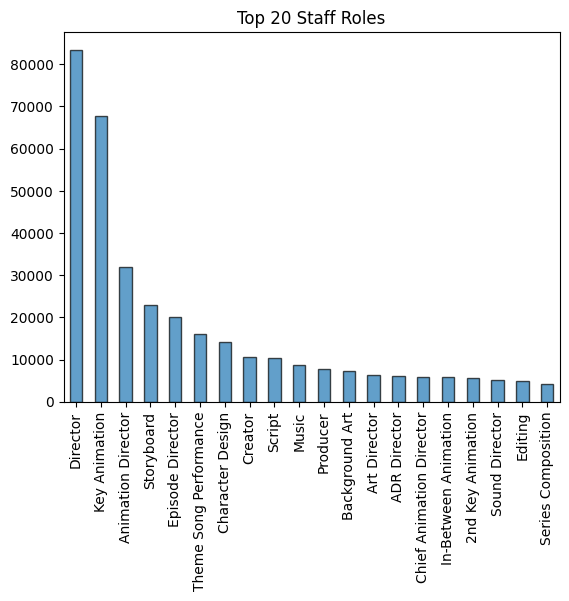

In [16]:
print(df_OneHotStaffRoles.sum().sort_values(ascending=False))

df_OneHotStaffRoles.sum().sort_values(ascending=False)[:20].plot(kind='bar', edgecolor='black', alpha=0.7)
plt.title('Top 20 Staff Roles')
plt.show()

In [17]:
df_Staff = df_Staff.reset_index().drop(columns=['index', 'Roles']).join(
    df_OneHotStaffRoles
)
df_Staff

,Anime_ID,Title,Type,Season,Year,Score,Members,Personnel_ID,Personnel_Name,Script,...,Character Design,Animation Director,Co-Director,Recording Assistant,Assistant Animation Director,Setting Manager,Sound Manager,Art Director,Assistant Producer,Special Effects
0,10547,Oretachi ni Tsubasa wa Nai: Hadairo Ritsu Kyuu...,OVA,NaN,2011.0,6.39,13924.0,10000,Navel,0,...,0,0,0,0,0,0,0,0,0,0
1,9922,Oretachi ni Tsubasa wa Nai: Under the Innocent...,TV,Spring,2011.0,6.63,91565.0,10000,Navel,0,...,0,0,0,0,0,0,0,0,0,0
2,79,Shuffle!,TV,Summer,2005.0,7.01,285765.0,10000,Navel,0,...,0,0,0,0,0,0,0,0,0,0
3,1836,Shuffle! Memories,TV,Winter,2007.0,6.52,57551.0,10000,Navel,0,...,0,0,0,0,0,0,0,0,0,0
4,7396,Shuffle! Prologue,OVA,NaN,2005.0,6.64,18797.0,10000,Navel,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245272,532,Bishoujo Senshi Sailor Moon S,TV,Spring,1994.0,7.90,153180.0,9,Mitsuishi Kotono,0,...,0,0,0,0,0,0,0,0,0,0
245273,870,Dragon Half,OVA,NaN,1993.0,6.84,23683.0,9,Mitsuishi Kotono,0,...,0,0,0,0,0,0,0,0,0,0
245274,2759,Evangelion Movie 1: Jo,Movie,NaN,2007.0,8.00,589850.0,9,Mitsuishi Kotono,0,...,0,0,0,0,0,0,0,0,0,0
245275,2081,Makeruna! Makendou,OVA,NaN,1995.0,5.49,2251.0,9,Mitsuishi Kotono,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
df_Staff.to_csv(EXPORT_FOLDER + 'Staff_Records.csv')

In [19]:
df_Staff_MBA = df_Staff.copy()
df_Staff_MBA['Role'] = df_Staff_MBA.iloc[:,9:].idxmax(axis=1).str.replace('class_', '')

df_Staff_MBA = df_Staff_MBA[['Anime_ID', 'Title', 'Role', 'Personnel_ID', 'Personnel_Name']].groupby('Anime_ID').agg(list)
df_Staff_MBA['Title'] = df_Staff_MBA['Title'].apply(lambda x : x[0])
df_Staff_MBA.to_pickle(EXPORT_FOLDER + 'MBA_Staff.pkl')
df_Staff_MBA

,Title,Role,Personnel_ID,Personnel_Name
Anime_ID,,,,
1,Cowboy Bebop,"[Director, Key Animation, Key Animation, Key A...","[10020, 10136, 10223, 10224, 10226, 10311, 105...","[Patiño Marco, Itou Nobutake, Koujina Hiroshi,..."
5,Cowboy Bebop: Tengoku no Tobira,"[Director, Key Animation, Inserted Song Perfor...","[10020, 10090, 10114, 10263, 10928, 11123, 111...","[Patiño Marco, Muraki Yasushi, Matthew Scott, ..."
6,Trigun,"[Key Animation, Storyboard, Mechanical Design,...","[10088, 10277, 10284, 10285, 10286, 10553, 107...","[Kanno Toshiyuki, Abe Noriyuki, Jinguuji Noriy..."
7,Witch Hunter Robin,"[Key Animation, Script, Storyboard, Director, ...","[10285, 10289, 11134, 11341, 11342, 11343, 126...","[Nishimura Satoshi, Nozaki Tooru, Chigira Koui..."
8,Bouken Ou Beet,"[Producer, Director, Music, Producer, Script, ...","[12109, 12867, 14975, 16687, 29041, 2954, 2955...","[Watson Barry, Nagamine Tatsuya, Takaki Hirosh..."
...,...,...,...,...
61326,Dokodemo Makibao,"[Episode Director, Creator, Music]","[15269, 25665, 44577]","[FROGMAN, Tsunomaru, Matsuno Kyouhei]"
61327,Nomo no Kuni,"[Script, Director]","[40403, 48398]","[Suzumura Chika, Kanno Chiaki]"
61332,Aka no Kioku,"[Theme Song Arrangement, Director, Script, Sou...","[15095, 38889, 40830, 48462]","[Nakajima Nobuyuki, Izumida Kazuto, Oshiyama K..."
